In [1]:
!apt-get update -qq
!apt-get install -y tesseract-ocr
!apt-get install -y tesseract-ocr-eng
!pip install pytesseract pillow pandas matplotlib opencv-python

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr-eng is already the newest version (1:4.00~git30-7274cfa-1.1).
tesseract-ocr-eng set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [2]:
!tesseract --version

tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8


In [3]:
!rm -rf /content/medical-document-ocr-extraction
!git clone https://github.com/tarekmahfoudi/medical-document-ocr-extraction.git

Cloning into 'medical-document-ocr-extraction'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 87 (delta 17), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 4.47 MiB | 13.43 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [4]:
import os

project_path = "/content/medical-document-ocr-extraction"
raw_path = os.path.join(project_path, "data", "raw", "sample")
processed_path = os.path.join(project_path, "data", "processed", "sample_preprocessed")
results_path = os.path.join(project_path, "results")

os.makedirs(results_path, exist_ok=True)

image_files = [f for f in os.listdir(raw_path) if f.lower().endswith(".jpg")]

print("Number of images:", len(image_files))
print(image_files[:5])

Number of images: 20
['med_doc_bill_100401_noisy.jpg', 'med_doc_discharge_summary_200434_noisy.jpg', 'med_doc_bill_100407_noisy.jpg', 'med_doc_discharge_summary_200435_noisy.jpg', 'med_doc_discharge_summary_200436_noisy.jpg']


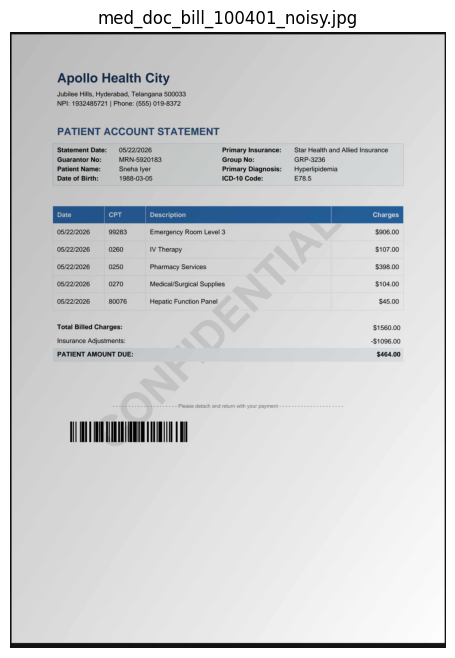

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import pytesseract

filename = image_files[0]
image_path = os.path.join(raw_path, filename)

img = Image.open(image_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title(filename)
plt.show()

In [6]:
text = pytesseract.image_to_string(img, lang="eng")

print(text[:2000])

Apollo Health City

Jubilee Hills, Hyderabad, Telangana 500033
NPI: 1932485721 | Phone: (555) 019-8372

PATIENT ACCOUNT STATEMENT

Statement Date: 05/22/2026 Primary Insurance:

Guarantor No: MRN-5920183 Group No:

Patient Name: Sneha lyer Primary Diagnosis:

Date of Birth: 1988-03-05 ICD-10 Code:

| AIS
BET} Description

05/22/2026 Emergency Room Level 3
05/22/2026 IV Therapy

05/22/2026 Pharmacy Services
05/22/2026 Medical/Surgical Supplies

05/22/2026 Hepatic Function Panel

Total Billed Charges:
Insurance Adjustments:

PATIENT AMOUNT DUE:

Please detach

Star Health and Allied Insurance
GRP-3236

Hyperlipidemia

E78.5

$906.00
$107.00
$398.00
$104.00

$45.00

$1560.00
-$1096.00
$464.00

 



In [7]:
import pandas as pd
import time

ocr_results = []

for filename in image_files:
    image_path = os.path.join(raw_path, filename)
    img = Image.open(image_path)

    start_time = time.time()
    text = pytesseract.image_to_string(img, lang="eng")
    duration = time.time() - start_time

    ocr_results.append({
        "filename": filename,
        "engine": "tesseract",
        "image_type": "raw",
        "ocr_text": text,
        "processing_time_seconds": duration
    })

df_ocr = pd.DataFrame(ocr_results)

df_ocr.head()

,filename,engine,image_type,ocr_text,processing_time_seconds
0,med_doc_bill_100401_noisy.jpg,tesseract,raw,"Apollo Health City\n\nJubilee Hills, Hyderabad...",2.929127
1,med_doc_discharge_summary_200434_noisy.jpg,tesseract,raw,Christian Medical College (CMC)\n\nDISCHARGE I...,8.103486
2,med_doc_bill_100407_noisy.jpg,tesseract,raw,\n \n \n \n \n \n \n \n \n \n \n...,2.087308
3,med_doc_discharge_summary_200435_noisy.jpg,tesseract,raw,\n\nApollo Health City\n\nDISCHARGE INSTRUCTI...,9.196109
4,med_doc_discharge_summary_200436_noisy.jpg,tesseract,raw,\n\nLilavati Hospital\n\nDISCHARGE INSTRUCTIO...,6.936345


In [8]:
output_csv = os.path.join(results_path, "ocr_tesseract_raw.csv")

df_ocr.to_csv(output_csv, index=False)

print("Saved to:", output_csv)

Saved to: /content/medical-document-ocr-extraction/results/ocr_tesseract_raw.csv


In [9]:
pd.read_csv(output_csv).head()

,filename,engine,image_type,ocr_text,processing_time_seconds
0,med_doc_bill_100401_noisy.jpg,tesseract,raw,"Apollo Health City\n\nJubilee Hills, Hyderabad...",2.929127
1,med_doc_discharge_summary_200434_noisy.jpg,tesseract,raw,Christian Medical College (CMC)\n\nDISCHARGE I...,8.103486
2,med_doc_bill_100407_noisy.jpg,tesseract,raw,\n \n \n \n \n \n \n \n \n \n \n...,2.087308
3,med_doc_discharge_summary_200435_noisy.jpg,tesseract,raw,\n\nApollo Health City\n\nDISCHARGE INSTRUCTI...,9.196109
4,med_doc_discharge_summary_200436_noisy.jpg,tesseract,raw,\n\nLilavati Hospital\n\nDISCHARGE INSTRUCTIO...,6.936345


In [10]:
for i in range(3):
    print("=" * 80)
    print("FILE:", df_ocr.loc[i, "filename"])
    print("=" * 80)
    print(df_ocr.loc[i, "ocr_text"][:1500])
    print("\n")

FILE: med_doc_bill_100401_noisy.jpg
Apollo Health City

Jubilee Hills, Hyderabad, Telangana 500033
NPI: 1932485721 | Phone: (555) 019-8372

PATIENT ACCOUNT STATEMENT

Statement Date: 05/22/2026 Primary Insurance:

Guarantor No: MRN-5920183 Group No:

Patient Name: Sneha lyer Primary Diagnosis:

Date of Birth: 1988-03-05 ICD-10 Code:

| AIS
BET} Description

05/22/2026 Emergency Room Level 3
05/22/2026 IV Therapy

05/22/2026 Pharmacy Services
05/22/2026 Medical/Surgical Supplies

05/22/2026 Hepatic Function Panel

Total Billed Charges:
Insurance Adjustments:

PATIENT AMOUNT DUE:

Please detach

Star Health and Allied Insurance
GRP-3236

Hyperlipidemia

E78.5

$906.00
$107.00
$398.00
$104.00

$45.00

$1560.00
-$1096.00
$464.00

 



FILE: med_doc_discharge_summary_200434_noisy.jpg
Christian Medical College (CMC)

DISCHARGE INSTRUCTIONS & CLINICAL SUMMARY

Patient: MRN: DOB:
Priya Patel MRN-4920184 1990-08-25

1. CHIEF COMPLAINT & HISTORY OF PRESENT ILLNESS

Patient presented to the emer

## First OCR experiment with Tesseract

In this notebook, I applied Tesseract OCR to the raw noisy medical document images.

The objective was to extract text from scanned-like medical documents and save the OCR output into a structured CSV file.

At this stage, the OCR quality is not expected to be perfect. The goal is to observe common OCR errors such as:

- missing text;
- incorrect characters;
- difficulty with tables;
- problems caused by noise or low contrast;
- layout-related errors.

The next step will be to compare OCR results between raw images and preprocessed images.